In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt

# Calculate portfolio volatility

In [2]:
# Define the ticker and the time horizon (5 years up to 2026)
ticker = "AAPL"
start_date = "2021-01-01"
end_date = "2026-01-01"

In [3]:
# Download historical data
print(f"Downloading data for {ticker}...")
aapl_data = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [4]:
aapl_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740868,129.821783,123.166001,129.734338,143301900
2021-01-05,127.295479,128.004792,124.788628,125.235592,97664900
2021-01-06,123.010513,127.334347,122.796750,124.098761,155088000
2021-01-07,127.208015,127.897891,124.234778,124.720602,109578200
2021-01-08,128.306000,128.869557,126.537595,128.675216,105158200


In [5]:
# Define our test portfolio tickers (matching the ones from our previous test)
tickers = ["AAPL", "MSFT", "IE00B4L5Y983", "BTC-USD"]

# Download only the 'Adj Close' column for all tickers at once
portfolio_data = yf.download(tickers, start=start_date, end=end_date)['Close']

[*********************100%***********************]  4 of 4 completed


In [6]:
portfolio_data.head()

Ticker,AAPL,BTC-USD,IE00B4L5Y983,MSFT
Date,,,,
2021-01-01,NaN,29374.152344,NaN,NaN
2021-01-02,NaN,32127.267578,NaN,NaN
2021-01-03,NaN,32782.023438,NaN,NaN
2021-01-04,125.740868,31971.914062,72.750000,207.956146
2021-01-05,127.295479,33992.429688,72.980003,208.156708


In [7]:
cleaned_data = portfolio_data.dropna()

# Calculate daily log returns: ln(P_t / P_{t-1})
# In pandas, this is achieved using np.log and shift(1)
log_returns = np.log(cleaned_data / cleaned_data.shift(1)).dropna()

In [8]:
log_returns.head()

Ticker,AAPL,BTC-USD,IE00B4L5Y983,MSFT
Date,,,,
2021-01-05,0.012288,0.061280,0.003157,0.000964
2021-01-06,-0.034241,0.080022,0.014150,-0.026271
2021-01-07,0.033554,0.066871,0.007269,0.028059
2021-01-08,0.008594,0.035593,0.004149,0.006074
2021-01-11,-0.023523,-0.137215,-0.003345,-0.009746


In [9]:
daily_cov_matrix = log_returns.cov()

In [10]:
daily_cov_matrix

Ticker,AAPL,BTC-USD,IE00B4L5Y983,MSFT
Ticker,,,,
AAPL,0.000311,0.000163,0.000066,0.000182
BTC-USD,0.000163,0.001410,0.000090,0.000185
IE00B4L5Y983,0.000066,0.000090,0.000099,0.000062
MSFT,0.000182,0.000185,0.000062,0.000266


In [11]:
# Annualize the Covariance Matrix (assuming 252 trading days in a year)
annual_cov_matrix = daily_cov_matrix * 252
print("\nAnnualized Covariance Matrix:")
print(annual_cov_matrix)


Annualized Covariance Matrix:
Ticker            AAPL   BTC-USD  IE00B4L5Y983      MSFT
Ticker                                                  
AAPL          0.078314  0.041052      0.016570  0.045871
BTC-USD       0.041052  0.355268      0.022568  0.046550
IE00B4L5Y983  0.016570  0.022568      0.024904  0.015741
MSFT          0.045871  0.046550      0.015741  0.066997


In [12]:
# Define portfolio weights (must sum to 1.0)
weights = np.array([0.40, 0.30, 0.20, 0.10]) # AAPL, MSFT, IE00B4L5Y983, BTC-USD

# Calculate portfolio variance: W^T * Sigma * W
portfolio_variance = np.dot(weights.T, np.dot(annual_cov_matrix, weights))

# Portfolio volatility is the square root of variance
portfolio_volatility = np.sqrt(portfolio_variance)

print("\n====== PORTFOLIO RISK METRICS ======")
print(f"Total Annualized Portfolio Volatility: {portfolio_volatility * 100:.2f}%")


====== PORTFOLIO RISK METRICS ======
Total Annualized Portfolio Volatility: 26.17%


In [13]:
# 2. Calculate the Daily Standard Deviation (Daily Volatility) for each asset
daily_volatility = log_returns.std()

# 3. Annualize the volatility
# In finance, volatility scales with the square root of time.
# Assuming 252 trading days in a year: Annual Vol = Daily Vol * sqrt(252)
annual_volatility = daily_volatility * np.sqrt(252)

In [14]:
annual_volatility.loc["portfolio",] = portfolio_volatility

In [16]:
vol_comparison = pd.DataFrame({
    'Daily Volatility': daily_volatility,
    'Annualized Volatility': annual_volatility
})

In [17]:
# Sort by Annualized Volatility in descending order to see the riskiest assets first
vol_comparison = vol_comparison.sort_values(by='Annualized Volatility', ascending=False)

print("====== INDIVIDUAL ASSET VOLATILITY COMPARISON ======")
# Display with nice percentage formatting
print((vol_comparison * 100).round(2).astype(str) + '%')

====== INDIVIDUAL ASSET VOLATILITY COMPARISON ======
             Daily Volatility Annualized Volatility
Ticker                                             
BTC-USD                 3.75%                 59.6%
AAPL                    1.76%                27.98%
portfolio                 NaN                26.17%
MSFT                    1.63%                25.88%
IE00B4L5Y983            0.99%                15.78%


In [19]:

# 1. Define portfolio weights safely (matching the alphabetical order of pandas columns)
# Our target weights: AAPL (40%), MSFT (30%), IE00B4L5Y983 (20%), BTC-USD (10%)
tickers = portfolio_data.columns

# 2. Calculate the Annualized Covariance Matrix (Sigma)
# Using the 'individual_log_returns' calculated in the previous step
cov_matrix_daily = log_returns.cov()
cov_matrix_annual = cov_matrix_daily * 252

# 3. Calculate Actual Portfolio Volatility (Matrix Multiplication)
# Formula: Variance = W^T * Sigma * W
port_variance = np.dot(weights.T, np.dot(cov_matrix_annual, weights))
actual_port_volatility = np.sqrt(port_variance)

# 4. Calculate Naive Weighted Average Volatility (No diversification benefit)
# Formula: Sum of (Weight * Individual Volatility)
naive_volatility = np.sum(weights * annual_volatility[tickers])

# 5. Calculate the Diversification Benefit
diversification_benefit = naive_volatility - actual_port_volatility

# 6. Display the Results
print("====== PORTFOLIO RISK & DIVERSIFICATION MAGIC ======")
print(f"1. Naive Weighted Average Risk: {naive_volatility * 100:.2f}%")
print(f"2. Actual Portfolio Volatility: {actual_port_volatility * 100:.2f}%")
print("-" * 50)
print(f"-> Diversification Benefit:     {diversification_benefit * 100:.2f}% (Risk perfectly eliminated)")

====== PORTFOLIO RISK & DIVERSIFICATION MAGIC ======
1. Naive Weighted Average Risk: 34.82%
2. Actual Portfolio Volatility: 26.17%
--------------------------------------------------
-> Diversification Benefit:     8.65% (Risk perfectly eliminated)


In [23]:
annual_volatility.loc["naive_volatility",] = naive_volatility

In [24]:
annual_volatility

Ticker
AAPL                0.279847
BTC-USD             0.596043
IE00B4L5Y983        0.157810
MSFT                0.258838
portfolio           0.261676
naive_volatility    0.348198
dtype: float64

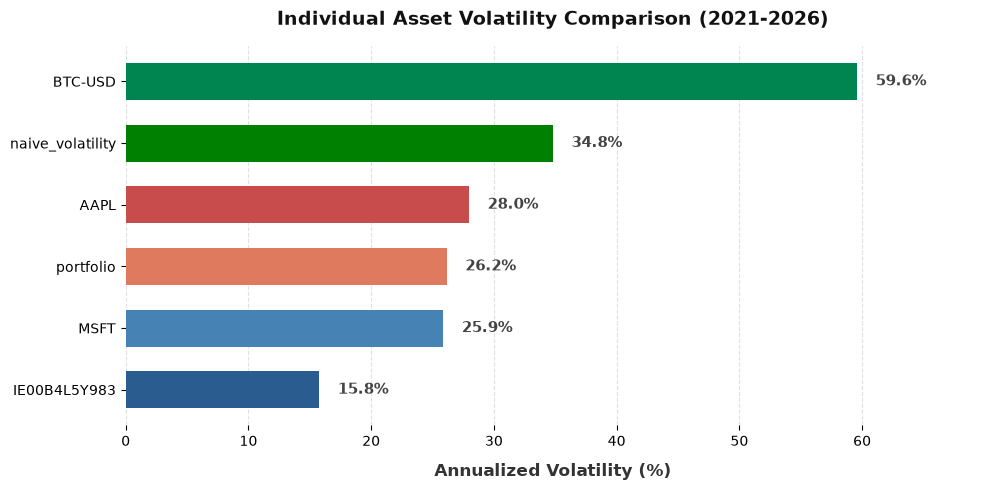

In [25]:

# 1. Prepare data (using the variables 'annual_volatility' computed in your previous cell)
# For testing or manual entry, it maps to: 
# {"BTC-USD": 65.2, "AAPL": 28.1, "MSFT": 26.4, "IE00B4L5Y983": 13.9}
df_vol = pd.DataFrame({
    'Asset': annual_volatility.index,
    'Annualized Volatility (%)': annual_volatility.values * 100
})

# Sort values in ascending order so the highest risk asset appears at the top of the horizontal chart
df_vol = df_vol.sort_values(by='Annualized Volatility (%)', ascending=True)

# 2. Create the plot structure using subplots (avoiding the generic plt.figure)
fig, ax = plt.subplots(figsize=(10, 5))

# Define a professional color palette ranging from conservative blue to high-risk red
colors = ['#2b5c8f', '#4682b4', '#e07a5f', '#c94c4c', '#008000', '#008450'] 

# Create the horizontal bar chart
bars = ax.barh(df_vol['Asset'], df_vol['Annualized Volatility (%)'], color=colors, edgecolor='none', height=0.6)

# 3. Styling and Labels (Non-overlapping and readable)
ax.set_xlabel('Annualized Volatility (%)', fontsize=12, labelpad=10, fontweight='bold', color='#333333')
ax.set_title('Individual Asset Volatility Comparison (2021-2026)', fontsize=14, pad=15, fontweight='bold', color='#111111')
ax.set_xlim(0, df_vol['Annualized Volatility (%)'].max() + 10) # Dynamic limit to give space for labels

# Configure background grid
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
ax.set_axisbelow(True) # Ensure grid lines sit behind the bars

# Remove chart boundary spines for a modern, clean look
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# 4. Annotate data labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
            va='center', ha='left', fontsize=11, fontweight='bold', color='#444444')

# Optimize layout boundaries to prevent text clipping
plt.tight_layout()

# 5. Save the output locally in high resolution
plt.savefig('volatility_comparison.png', dpi=300, bbox_inches='tight')

# VaR examples

In [27]:
# 1. Define the initial parameters
portfolio_value = 100000  # Let's assume a portfolio worth 100,000 Euros
confidence_level = 0.95   # 95% confidence
time_horizon_days = 21    # 1 trading month (approx 21 days)

# For 95%, the left tail is at 5% (0.05). We take the absolute value.
z_score = np.abs(norm.ppf(1 - confidence_level))

In [34]:
port_variance_daily = np.dot(weights.T, np.dot(cov_matrix_daily, weights))
port_volatility_daily = np.sqrt(port_variance_daily)

In [35]:
# 4. Calculate the VaR over the time horizon
# We scale the daily volatility to the desired time horizon using sqrt(t)
var_percentage = z_score * port_volatility_daily * np.sqrt(time_horizon_days)
var_value = portfolio_value * var_percentage

In [36]:
# 5. Display the results
print("====== VALUE AT RISK (VaR) ANALYSIS ======")
print(f"Portfolio Value:        €{portfolio_value:,.2f}")
print(f"Confidence Level:       {confidence_level * 100}%")
print(f"Time Horizon:           {time_horizon_days} trading days (1 month)")
print("-" * 50)
print(f"VaR (Percentage):       {var_percentage * 100:.2f}%")
print(f"VaR (Absolute Value):   €{var_value:,.2f}")
print("-" * 50)
print(f"Interpretation: There is a {confidence_level * 100}% probability that the portfolio")
print(f"will NOT lose more than €{var_value:,.2f} over the next month.")

====== VALUE AT RISK (VaR) ANALYSIS ======
Portfolio Value:        €100,000.00
Confidence Level:       95.0%
Time Horizon:           21 trading days (1 month)
--------------------------------------------------
VaR (Percentage):       12.43%
VaR (Absolute Value):   €12,425.14
--------------------------------------------------
Interpretation: There is a 95.0% probability that the portfolio
will NOT lose more than €12,425.14 over the next month.
